In [3]:
import pandas as pd

In [15]:
df = pd.read_csv("./data_raw/test_table.csv", index_col=0)

print(f"Данные успешно загружены! Размер: {df.shape}")
print(f"Занимаемая память: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Данные успешно загружены! Размер: (17430, 241)
Занимаемая память: 94.27 MB


In [16]:
df.head(5)

,Unnamed: 0,Код пациента,Name,Age,Sex,STEMI,ЧКВ,Вид STEMI,Инфаркт-зависимая артерия,Поражение ствола,...,BEVenMin (b),BEVenMin,BEVenMax (b),BEVenMax,HCO3VenMin (b),HCO3VenMin,HCO3VenMax (b),HCO3VenMax,BNP (b),BNP
0,47,17-12105,Бабаев СН,59.0,М,Нет,Да,NaN,2,Нет,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,106,17-17180,Ползиков СВ,58.0,М,Нет,Да,NaN,2,Нет,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,158,15536,Анфёров ЮА,74.0,М,Нет,Да,NaN,ОВ - Несовадает,Нет,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,461,21-8249,Арутюнян МА,66.0,NaN,Нет,Да,NaN,ПМЖВ - Несовадает,Нет,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,568,17-20825,Кондрашин АА,31.0,М,Нет,Нет,NaN,0,Нет,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
df.set_index('Unnamed: 0', inplace=True)

In [18]:
df.head(5)

,Код пациента,Name,Age,Sex,STEMI,ЧКВ,Вид STEMI,Инфаркт-зависимая артерия,Поражение ствола,Количество пораженных сосудов(Syntax),...,BEVenMin (b),BEVenMin,BEVenMax (b),BEVenMax,HCO3VenMin (b),HCO3VenMin,HCO3VenMax (b),HCO3VenMax,BNP (b),BNP
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
47,17-12105,Бабаев СН,59.0,М,Нет,Да,NaN,2,Нет,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106,17-17180,Ползиков СВ,58.0,М,Нет,Да,NaN,2,Нет,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
158,15536,Анфёров ЮА,74.0,М,Нет,Да,NaN,ОВ - Несовадает,Нет,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
461,21-8249,Арутюнян МА,66.0,NaN,Нет,Да,NaN,ПМЖВ - Несовадает,Нет,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
568,17-20825,Кондрашин АА,31.0,М,Нет,Нет,NaN,0,Нет,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
%pip install optuna

  Using cached colorlog-6.10.1-py3-none-any.whl.metadata (11 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 902.4 kB/s eta 0:00:00a 0:00:01
Using cached colorlog-6.10.1-py3-none-any.whl (11 kB)
Note: you may need to restart the kernel to use updated packages.


In [19]:
import pandas as pd
import numpy as np
import optuna
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (recall_score, precision_score, f1_score,
                             roc_auc_score, precision_recall_curve, auc,
                             confusion_matrix, classification_report)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.style.use('seaborn-v0_8-whitegrid')

In [20]:
def clean_column_names(df):
    """
    Очищает имена колонок от символов, которые не принимает XGBoost
    """
    new_columns = []
    for col in df.columns:
        # Удаляем запрещенные символы
        clean_col = col.replace('[', '_').replace(']', '_').replace('<', '_lt_')
        # Удаляем другие потенциально проблемные символы
        clean_col = clean_col.replace('>', '_gt_').replace(' ', '_').replace(':', '_')
        clean_col = clean_col.replace('(', '_').replace(')', '_').replace(',', '_')
        clean_col = clean_col.replace('{', '_').replace('}', '_').replace('|', '_')
        # Удаляем последовательные подчеркивания
        clean_col = '_'.join(filter(None, clean_col.split('_')))
        # Удаляем подчеркивания в начале и конце
        clean_col = clean_col.strip('_')
        # Если имя начинается с цифры, добавляем префикс
        if clean_col and clean_col[0].isdigit():
            clean_col = 'f_' + clean_col
        new_columns.append(clean_col)
    
    # Создаем копию DataFrame с новыми именами колонок
    df_clean = df.copy()
    df_clean.columns = new_columns
    return df_clean

In [21]:
# 1. Кодирование цели и удаление пропусков
df['Смерть'] = df['Смерть'].map({'Да': 1, 'Нет': 0})
df = df.dropna(subset=['Смерть']).reset_index(drop=True)

df = clean_column_names(df)

# 2. Разделение на X, y, groups
X = df.drop(columns=['Смерть', 'Код_пациента'])
y = df['Смерть']
groups = df['Name']

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# 4. Групповое разбиение: Train(60%) / Val(20%) / Test(20%)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_val_idx, test_idx = next(gss1.split(X, y, groups))

X_train_val, y_train_val, g_train_val = X.iloc[train_val_idx], y.iloc[train_val_idx], groups.iloc[train_val_idx]
X_test, y_test, g_test = X.iloc[test_idx], y.iloc[test_idx], groups.iloc[test_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42) # 0.25 от 80% = 20%
train_idx, val_idx = next(gss2.split(X_train_val, y_train_val, g_train_val))

X_train, y_train, g_train = X_train_val.iloc[train_idx], y_train_val.iloc[train_idx], g_train_val.iloc[train_idx]
X_val, y_val, g_val = X_train_val.iloc[val_idx], y_train_val.iloc[val_idx], g_train_val.iloc[val_idx]

# 5. Безопасное кодирование категорий (ТОЛЬКО после разбиения!)
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
if cat_cols:
    X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols].astype(str))
    X_val[cat_cols]   = encoder.transform(X_val[cat_cols].astype(str))
    X_test[cat_cols]  = encoder.transform(X_test[cat_cols].astype(str))

# Баланс классов для весов
spw = (y_train == 0).sum() / max(1, (y_train == 1).sum())
print(f"✅ Разбиение завершено. Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"📊 Баланс Train: {y_train.mean():.3f} | scale_pos_weight ≈ {spw:.2f}")

✅ Разбиение завершено. Train: 9972 | Val: 3329 | Test: 3312
📊 Баланс Train: 0.035 | scale_pos_weight ≈ 27.41


In [35]:
def optimize_model(model_name, trial):
    """Единая objective-функция для Optuna (исправлено под API >= 1.6)"""
    if model_name == 'XGBoost':
        params = {
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.5, log=True),
            'max_depth': trial.suggest_int('max_depth', 2, 80),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 70),
            'subsample': trial.suggest_float('subsample', 0.1, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.1, 1.0),
            'gamma': trial.suggest_float('gamma', 0.0, 10.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 30.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 30.0, log=True),
            'scale_pos_weight': trial.suggest_float('scale_pos_weight', spw*0.5, spw*2.0),
            'tree_method': 'hist', 'eval_metric': 'logloss',
            'random_state': 42, 'verbosity': 0,
            'callbacks': [xgb.callback.EarlyStopping(rounds=50, save_best=True)]
        }

        model = XGBClassifier(**params)
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        
    elif model_name == 'LightGBM':
        max_depth = trial.suggest_int('max_depth', 3, 10)
        
        # Безопасная динамическая граница: не больше 2^depth и не больше практического потолка
        max_leaves = max(15, min(2**max_depth, 255))  # 255 покрывает 99% задач, >512 почти всегда вредит
        num_leaves = trial.suggest_int('num_leaves', 15, max_leaves)
        
        params = {
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.5, log=True),
            'num_leaves': num_leaves,
            'max_depth': max_depth,
            'min_child_samples': trial.suggest_int('min_child_samples', 1, 300),
            'subsample': trial.suggest_float('subsample', 0.1, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.1, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 30.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 30.0, log=True),
            'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 1.0),
            'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced', {0:1, 1:spw}]),
            'random_state': 42, 'verbose': -1
        }
        model = LGBMClassifier(**params)
        # ✅ LightGBM принимает callbacks в fit()
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
        
    elif model_name == 'CatBoost':
        params = {
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.5, log=True),
            'depth': trial.suggest_int('depth', 1, 100),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 30.0, log=True),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 100),
            'subsample': trial.suggest_float('subsample', 0.1, 1.0),
            'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.1, 1.0),
            'border_count': trial.suggest_int('border_count', 32, 512),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
            'random_strength': trial.suggest_float('random_strength', 0.0, 50.0),
            'class_weights': trial.suggest_categorical('class_weights', [None, [1, spw]]),
            'boosting_type': 'Ordered', 'eval_metric': 'Logloss',
            'random_state': 42, 'verbose': False
        }
        model = CatBoostClassifier(**params)
        # ✅ CatBoost использует early_stopping_rounds в fit()
        model.fit(X_train, y_train, eval_set=(X_val, y_val),
                  early_stopping_rounds=50, use_best_model=True, verbose=False)
        
    # Метрика оптимизации: PR-AUC на валидации
    proba = model.predict_proba(X_val)[:, 1]
    prec, rec, _ = precision_recall_curve(y_val, proba)
    return auc(rec, prec)

import optuna
import optuna.visualization as opt_vis

best_params = {}
studies = {}  # ← сохраняем study для графиков

for name in ['XGBoost', 'LightGBM', 'CatBoost']:
    print(f"\n🔍 Тюнинг {name}...")
    study = optuna.create_study(direction='maximize', study_name=f'{name}_study')
    study.optimize(lambda trial: optimize_model(name, trial), n_trials=500, show_progress_bar=True)
    
    best_params[name] = study.best_params
    studies[name] = study  # ← сохраняем
    print(f"✅ Best PR-AUC: {study.best_value:.4f}")


🔍 Тюнинг XGBoost...


  0%|          | 0/500 [00:00<?, ?it/s]

✅ Best PR-AUC: 0.6911

🔍 Тюнинг LightGBM...


  0%|          | 0/500 [00:00<?, ?it/s]

✅ Best PR-AUC: 0.7158

🔍 Тюнинг CatBoost...


  0%|          | 0/500 [00:00<?, ?it/s]

[W 2026-04-25 05:29:49,015] Trial 0 failed with parameters: {'learning_rate': 0.006293545146908027, 'depth': 47, 'l2_leaf_reg': 1.3595026381172068, 'min_data_in_leaf': 24, 'subsample': 0.10777430816978727, 'colsample_bylevel': 0.9466341398873047, 'border_count': 460, 'bagging_temperature': 0.4764621171719511, 'random_strength': 33.64765057846086, 'class_weights': [1, np.float64(27.41025641025641)]} because of the following error: CatBoostError('catboost/private/libs/options/oblivious_tree_options.cpp:128: Maximum tree depth is 16').
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_1644661/2130797945.py", line 81, in <lambda>
    study.optimize(lambda trial: optimize_model(name, trial), n_trials=500, show_progress_bar=True)
                                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_164466

CatBoostError: catboost/private/libs/options/oblivious_tree_options.cpp:128: Maximum tree depth is 16

In [ ]:
for name, study in studies.items():
    print(f"\n📈 Интерактивные графики Optuna для {name}:")
    
    # 1. История оптимизации
    fig1 = opt_vis.plot_optimization_history(study)
    fig1.update_layout(title=f'Optimization History | {name}', height=400)
    fig1.show()
    
    # 2. Важность гиперпараметров (какие параметры сильнее всего влияют на метрику)
    if len(study.trials) > 2:
        fig2 = opt_vis.plot_param_importances(study)
        fig2.update_layout(title=f'Parameter Importances | {name}', height=400)
        fig2.show()
    
    # 3. Параллельные координаты (визуализация многомерного поиска)
    fig3 = opt_vis.plot_parallel_coordinate(study)
    fig3.update_layout(title=f'Parallel Coordinate | {name}', height=500)
    fig3.show()
    
    # 4. Slice plot (влияние каждого параметра на целевую метрику)
    fig4 = opt_vis.plot_slice(study)
    fig4.update_layout(title=f'Slice Plot | {name}', height=450)
    fig4.show()
    
    # 5. Contour plot (взаимодействие двух самых важных параметров)
    top_params = list(study.best_params.keys())[:2]
    if len(top_params) >= 2:
        fig5 = opt_vis.plot_contour(study, params=top_params)
        fig5.update_layout(title=f'Contour ({top_params[0]} vs {top_params[1]}) | {name}', height=450)
        fig5.show()


📈 Интерактивные графики Optuna для XGBoost:



📈 Интерактивные графики Optuna для LightGBM:



📈 Интерактивные графики Optuna для CatBoost:


In [26]:
final_models = {}
thresholds = {}

for name, params in best_params.items():
    print(f"\n🚀 Финальное обучение {name}...")
    
    # Копируем, чтобы не менять исходный словарь best_params
    model_params = params.copy()
    
    if name == 'XGBoost':
        # XGBoost принимает scale_pos_weight напрямую (имя совпадает с Optuna)
        model = XGBClassifier(
            **model_params,
            tree_method='hist',
            eval_metric='logloss',
            random_state=42,
            verbosity=0,
            callbacks=[xgb.callback.EarlyStopping(rounds=50, save_best=True)]
        )
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        
    elif name == 'LightGBM':
        # Преобразуем pos_weight -> class_weight
        pw = model_params.pop('pos_weight')
        model_params['class_weight'] = {0: 1, 1: pw}
        
        model = LGBMClassifier(**model_params, random_state=42, verbose=-1)
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
        
    elif name == 'CatBoost':
        # Преобразуем pos_weight -> class_weights
        pw = model_params.pop('pos_weight')
        model_params['class_weights'] = [1, pw]
        
        model = CatBoostClassifier(**model_params, random_state=42, verbose=False, eval_metric='Logloss')
        model.fit(X_train, y_train, eval_set=(X_val, y_val),
                  early_stopping_rounds=50, use_best_model=True)
        
    final_models[name] = model
    
    # 🔑 Оптимизация порога НА VALIDATION
    proba_val = model.predict_proba(X_val)[:, 1]
    prec_curve, rec_curve, thr_curve = precision_recall_curve(y_val, proba_val)
    
    min_precision = 0.4  # Настройте под клинические требования
    best_thr, best_rec = 0.5, 0.0
    for p, r, t in zip(prec_curve, rec_curve, thr_curve):
        if p >= min_precision and r > best_rec:
            best_rec = r
            best_thr = t
            
    thresholds[name] = best_thr
    print(f"🎯 Оптимальный порог ({name}): {best_thr:.3f} | Recall: {best_rec:.3f}")


🚀 Финальное обучение XGBoost...
🎯 Оптимальный порог (XGBoost): 0.139 | Recall: 0.759

🚀 Финальное обучение LightGBM...
🎯 Оптимальный порог (LightGBM): 0.111 | Recall: 0.741

🚀 Финальное обучение CatBoost...
🎯 Оптимальный порог (CatBoost): 0.652 | Recall: 0.796


,Model,Threshold,Recall,Precision,F1,PR-AUC,ROC-AUC,FN (пропущенные смерти),FP (ложные тревоги)
0,XGBoost,0.139,0.871,0.474,0.614,0.794,0.978,15,112
1,LightGBM,0.111,0.845,0.483,0.614,0.785,0.973,18,105
2,CatBoost,0.652,0.810,0.443,0.573,0.749,0.977,22,118


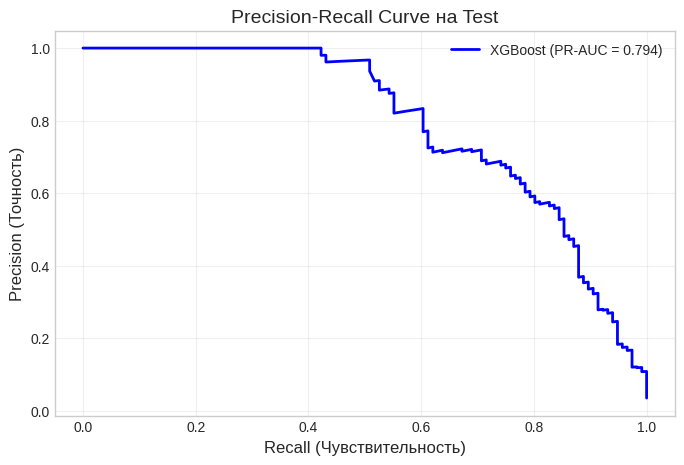

In [28]:
results = []
for name, model in final_models.items():
    thr = thresholds[name]
    proba_test = model.predict_proba(X_test)[:, 1]
    pred_test = (proba_test >= thr).astype(int)
    
    cm = confusion_matrix(y_test, pred_test)
    tn, fp, fn, tp = cm.ravel()
    rec = recall_score(y_test, pred_test)
    prec = precision_score(y_test, pred_test, zero_division=0)
    f1 = f1_score(y_test, pred_test)
    prec_curve, rec_curve, _ = precision_recall_curve(y_test, proba_test)
    pr_auc = auc(rec_curve, prec_curve)  # x=recall (монотонный), y=precision
    roc_auc = roc_auc_score(y_test, proba_test)
    
    results.append({
        'Model': name, 'Threshold': thr, 'Recall': rec, 'Precision': prec,
        'F1': f1, 'PR-AUC': pr_auc, 'ROC-AUC': roc_auc,
        'FN (пропущенные смерти)': fn, 'FP (ложные тревоги)': fp
    })

res_df = pd.DataFrame(results).sort_values('Recall', ascending=False)
display(res_df.style.background_gradient(cmap='Blues', subset=['Recall', 'PR-AUC']).format({
    'Threshold': '{:.3f}', 'Recall': '{:.3f}', 'Precision': '{:.3f}',
    'F1': '{:.3f}', 'PR-AUC': '{:.3f}', 'ROC-AUC': '{:.3f}'
}))

# Визуализация PR-кривой лучшей модели
best_model_name = res_df.iloc[0]['Model']
best_model = final_models[best_model_name]
proba_test = best_model.predict_proba(X_test)[:, 1]
prec, rec, _ = precision_recall_curve(y_test, proba_test)

plt.figure(figsize=(8,5))
plt.plot(rec, prec, 'b-', lw=2, label=f'{best_model_name} (PR-AUC = {auc(rec, prec):.3f})')
plt.xlabel('Recall (Чувствительность)', fontsize=12)
plt.ylabel('Precision (Точность)', fontsize=12)
plt.title('Precision-Recall Curve на Test', fontsize=14)
plt.legend(); plt.grid(alpha=0.3); plt.show()

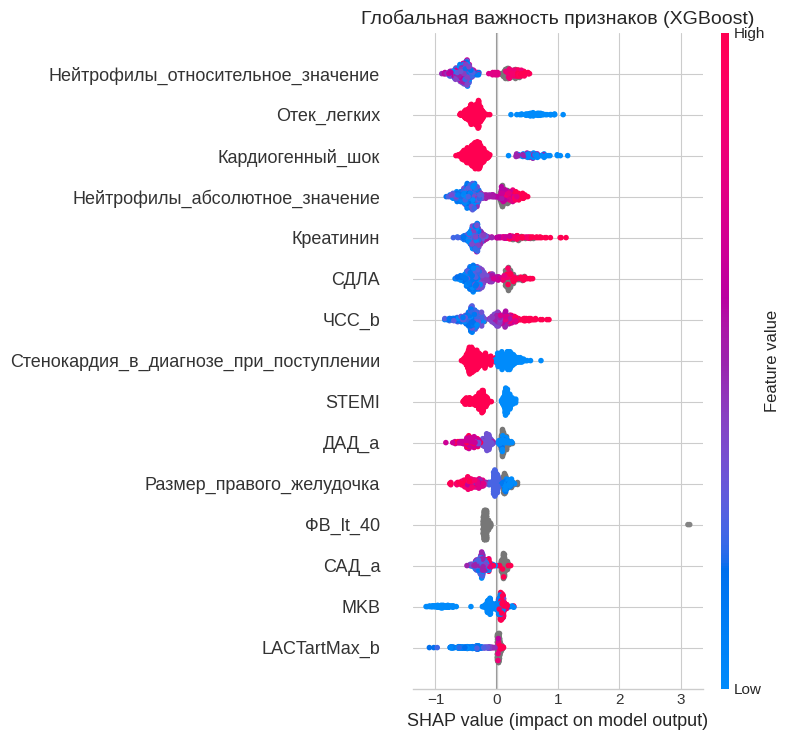

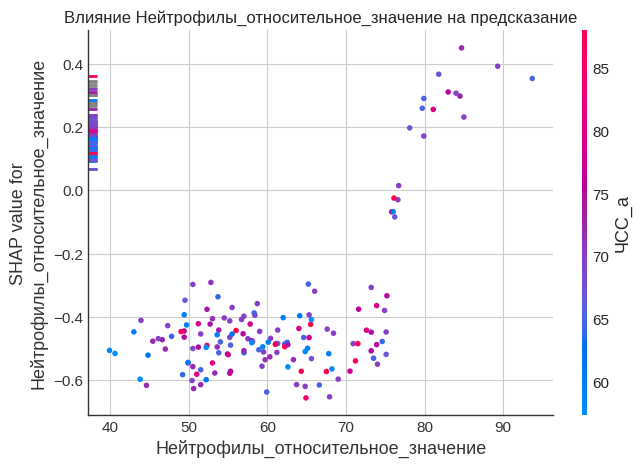

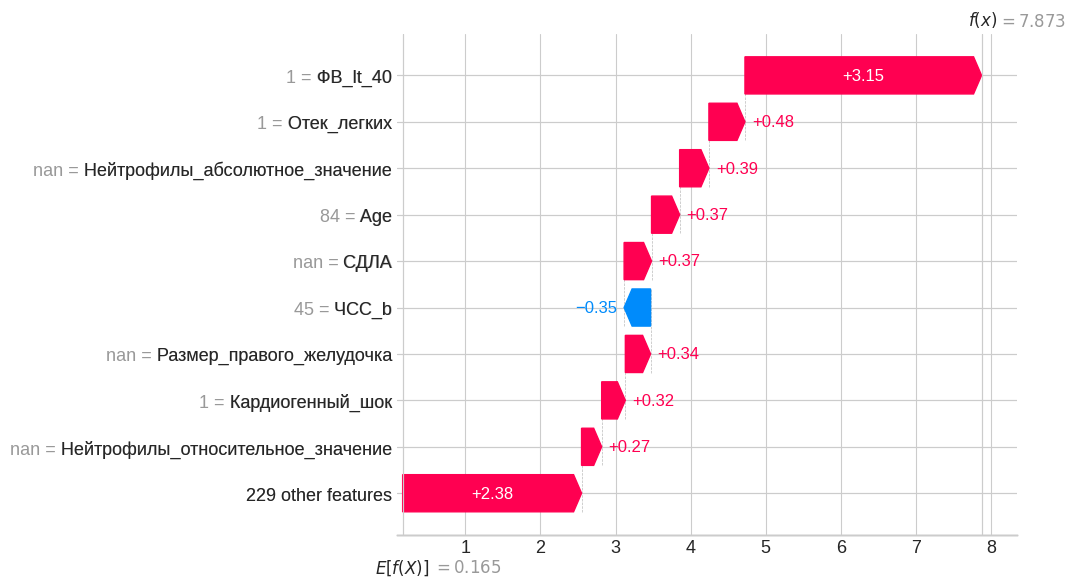

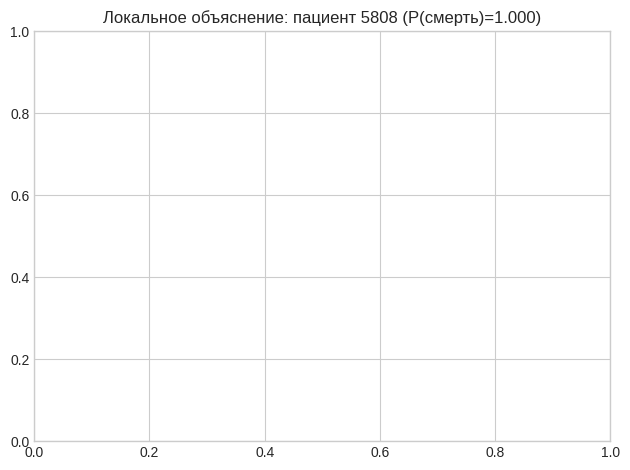

In [30]:
# Подготовка данных для SHAP (берём подвыборку для скорости)
X_val_sample = shap.sample(X_val, 500)

if best_model_name == 'CatBoost':
    # CatBoost возвращает SHAP с дополнительным столбцом base_value
    pool_val = catboost.Pool(X_val_sample, y_val.loc[X_val_sample.index])
    shap_vals = best_model.get_feature_importance(pool_val, type='ShapValues')
    expected_value = shap_vals[0, -1]
    shap_vals = shap_vals[:, :-1]
else:
    explainer = shap.TreeExplainer(best_model)
    shap_vals = explainer.shap_values(X_val_sample)
    expected_value = explainer.expected_value
    if isinstance(expected_value, np.ndarray): expected_value = expected_value[1] # для бинарной классификации

# 🌍 Глобальная важность (Beeswarm)
plt.figure()
shap.summary_plot(shap_vals, X_val_sample, plot_type='dot', max_display=15, show=False)
plt.title(f'Глобальная важность признаков ({best_model_name})', fontsize=14)
plt.tight_layout(); plt.show()

# 📉 Зависимость топ-признака
top_feat = X_val_sample.columns[np.abs(shap_vals).mean(axis=0).argmax()]
shap.dependence_plot(top_feat, shap_vals, X_val_sample, show=False)
plt.title(f'Влияние {top_feat} на предсказание', fontsize=12)
plt.show()

# 🧍 Локальное объяснение (пациент с высоким риском)
# 1. Находим позицию пациента с максимальной вероятностью смерти внутри X_val_sample
proba_sample = best_model.predict_proba(X_val_sample)[:, 1]
high_risk_pos = int(np.argmax(proba_sample))  # целочисленная позиция (0..499)
high_risk_idx = X_val_sample.index[high_risk_pos]

# 2. Берём SHAP-значения по позиции в numpy-массиве
shap_vals_single = shap_vals[high_risk_pos]

# 3. Визуализация
plt.figure()
shap.waterfall_plot(shap.Explanation(
    values=shap_vals_single,
    base_values=expected_value,
    data=X_val_sample.iloc[high_risk_pos].values,
    feature_names=X_val_sample.columns
), max_display=10)
plt.title(f'Локальное объяснение: пациент {high_risk_idx} (P(смерть)={proba_sample[high_risk_pos]:.3f})', fontsize=12)
plt.tight_layout()
plt.show()